In [116]:
import numpy as np
from numpy import genfromtxt
from numpy.linalg import norm
import math, random
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import initializers
import time

In [89]:
#spatial funcs for WoS

def closestPoint(v, s):
    u = s[1] - s[0]
    rate = max(0, min(u.dot(v - s[0])/u.dot(u), 1))
    return (s[0] + rate*(s[1] - s[0]))

def shortestDistance(v, segments):
    r = float("inf")
    for s in segments:
        u = closestPoint(v, s)
        if norm(v - u) < r:
            r = norm(v - u)
    return r

In [90]:
def pathGenerator(v, segments, g, eps = 0.001, maxSteps = 25, maxR = 10): 
    x0 = v
    path = []
    for step in range(0, maxSteps): 
        path.append(x0)
        r = min([shortestDistance(x0, segments), maxR])
        if r < eps: 
            return path, g(x0)
        theta = random.uniform(0, 2*math.pi)
        x0 = x0 + np.array([r * math.cos(theta), r * math.sin(theta)])
        
    #resample the path if length 0!!
    
    #return pathGenerator(v, segments, g)
    return [], 0

In [91]:
# set up the problem
segments = [np.array([[-1, -1], [-1, 1]]), np.array([[-1, -1], [1, -1]]), np.array([[1, -1], [1, 0]]), np.array([[-1, 1], [0, 1]]), np.array([[0, 1], [0, 0]]), np.array([[1, 0], [0, 0]])]

#v = np.array([0, 0])
def boundary(v):
    if v[0] >= -0.001 and v[1] >= -0.001:
        return 1
    else:
        return 0

In [92]:
tic = time.perf_counter()#timer
#####evenly distributed start places
#target = []
#width = range(1, 200)
#height = range(1, 200)
#for i in width:
#    for j in height:
#        target.append(np.array([i/100 - 1, j/100 - 1]))
        
#target = np.tile(target_core, [100, 1])
#print(target.shape)

#print(len(target))

###### pure random start places
#target = np.random.rand(40000, 2)
#target = 2* target - 1

#####QMC start places
import scipy.stats as stats
qmcGenerator = stats.qmc.Sobol(d=2)
target = qmcGenerator.random(n=100000)
target = 2* target - 1
target = target[(target[:,0] <= 0) | (target[:,1] <= 0)]
print(target.shape)

#####Single start place at center
#target = np.zeros((40000, 2))


(75000, 2)


/opt/anaconda3/envs/Python31014/lib/python3.10/site-packages/scipy/stats/_qmc.py:958: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  sample = self._random(n, workers=workers)


In [93]:
paths = []
boundaries = []
maxPath = 0;
for v in target:
    p, b = pathGenerator(v, segments, boundary)
    if len(p) != 0:
        paths.append(p)
        boundaries.append(b)
        if len(p) > maxPath:
            maxPath = len(p)


In [94]:
paths1 = np.zeros((len(paths), maxPath, 2))
for i in range(len(paths)):
    path = paths[i]
    npath = np.array(path)
    if len(path) < maxPath:
        npath = np.concatenate((npath, np.ones((maxPath - len(path), 2)) * np.array(path[len(path) - 1])))

    paths1[i] = npath

print("Total path amount: ")
print(paths1.shape)
tac = time.perf_counter()
print("WoSNN sample time: " + str(tac - tic))

Total path amount: 
(72069, 25, 2)
WoSNN sample time: 28.196760499995435


In [95]:
paths1 = paths1.reshape(-1, maxPath, 2).astype("float32")
boundary1 = np.array(boundaries).astype("float32")

In [96]:
class NN(keras.Model):
    def __init__(self, units):
        super(NN, self).__init__()
        self.layer1 = keras.layers.Dense(units[0])
        self.layer2 = keras.layers.Dense(units[1])
        self.layer3 = keras.layers.Dense(units[2])
        self.outputs = layers.Dense(3)

    def call(self, input_tensor, training):
        x = self.layer1(input_tensor)
        x = tf.nn.relu(x)
        x = self.layer2(x)
        x = tf.nn.relu(x)
        x = self.layer3(x)
        x = tf.nn.relu(x)
        x = self.outputs(x)
        #print(x.shape)
        return x

In [97]:
class Ysolver(keras.Model):
    # set y as a trainable variable, initialized randomly
    def __init__(self, layer):
        super(Ysolver, self).__init__()
        self.model = NN(layer)

        #self.y = tf.Variable(np.random.uniform(low=-1, high=1, size=[1, 1]),trainable = True, dtype ="float32")

    def call(self, path, training, batch):
        #print(path.shape)
        y_pred = self.model(path[:, 0], training)[:, 0]
        #print(y_pred.shape)
        for i in range(len(path[0]) - 1): ###input path should be (-1, 2) shaped nparray, no len()
            #y = self.Ymodel(path[:, i], training)
            #print(y.shape)
            #z_input = tf.concat([path[:, i],y], 1)
            z = self.model(path[:, i], training)[:, 1:3] #obtain gradients for steps
            diff = path[:, i + 1] - path[:, i]
            #print(diff.shape)
            add = z[:, 0]*diff[:, 0] + z[:, 1]*diff[:, 1] #accumulating
            #print(add.shape)
            y_pred += add

        return y_pred

In [98]:
class NNsolver(keras.Model):
    def __init__(self, paths, boundary):
        super(NNsolver, self).__init__()
        self.paths = paths
        self.boundary = np.array(boundary)
        self.model = Ysolver([32, 64, 128])
        self.optimizer = tf.keras.optimizers.legacy.Adam(learning_rate=3e-4 , epsilon=1e-8)

    def loss_fn(self, y_pred, y):
        delta = y_pred - y
        loss = tf.reduce_mean(tf.square(delta))
        return loss

    def train_step(self, cur_path, training, batch_size):           
        return self.model(cur_path, training, batch_size)

    def train(self, batch_size): 
        training_history = []
        for i in range((len(self.paths) - 1)//batch_size + 1):
            batch = batch_size
            if (i + 1) * batch_size > len(paths):
                batch = len(paths) - i * batch_size
            cur_path = self.paths[i*batch_size: i*batch_size + batch]
            cur_bound = self.boundary[i*batch_size: i*batch_size + batch]
                
            with tf.GradientTape() as tape:
                y_pred = self.train_step(cur_path, training = True, batch_size=batch)
                loss = self.loss_fn(y_pred, cur_bound)

            training_vars = self.model.trainable_variables 
            grad = tape.gradient(loss, training_vars)
            #print(grad)
            #print("----------------------------------------------------")
            self.optimizer.apply_gradients(zip(grad, training_vars))
            #print(self.model.Ymodel.trainable_variables)
            training_history.append(loss)

        return training_history

    def train_epoch(self, epoch, batch_size):
        for i in range(epoch):
            cur_history = self.train(batch_size)
            print("epoch: " + str(i) + " loss: "+ str(np.mean(np.array(cur_history))))


In [99]:
tic = time.perf_counter()
training = NNsolver(paths1, boundary1)
training.train_epoch(150, 2048)
tac = time.perf_counter()
print("WoSNN training time: " + str(tac - tic))

epoch: 0 loss: 0.23189504
epoch: 1 loss: 0.16227722
epoch: 2 loss: 0.09697795
epoch: 3 loss: 0.054191194
epoch: 4 loss: 0.03882117
epoch: 5 loss: 0.03251904
epoch: 6 loss: 0.028583266
epoch: 7 loss: 0.02581657
epoch: 8 loss: 0.023685042
epoch: 9 loss: 0.022036007
epoch: 10 loss: 0.02070824
epoch: 11 loss: 0.01958105
epoch: 12 loss: 0.018621173
epoch: 13 loss: 0.01780772
epoch: 14 loss: 0.017120102
epoch: 15 loss: 0.016545158
epoch: 16 loss: 0.016061017
epoch: 17 loss: 0.015661398
epoch: 18 loss: 0.01532561
epoch: 19 loss: 0.015045626
epoch: 20 loss: 0.014808137
epoch: 21 loss: 0.014601458
epoch: 22 loss: 0.014419068
epoch: 23 loss: 0.014255754
epoch: 24 loss: 0.014106116
epoch: 25 loss: 0.01397139
epoch: 26 loss: 0.013852471
epoch: 27 loss: 0.013743009
epoch: 28 loss: 0.013641514
epoch: 29 loss: 0.013549375
epoch: 30 loss: 0.01346558
epoch: 31 loss: 0.013388332
epoch: 32 loss: 0.013314892
epoch: 33 loss: 0.013244881
epoch: 34 loss: 0.013178861
epoch: 35 loss: 0.013116174
epoch: 36 loss

In [100]:
print(training.model.model(np.array([0.5, 0.5]).reshape([1, 2]).astype("float32")))

tf.Tensor([[2.0530193 1.7718796 2.2871006]], shape=(1, 3), dtype=float32)


In [101]:
tic = time.perf_counter()
width = range(101)
height = range(101)

X = []
Y = []
Z = []
for i in width:
    for j in height:
        X.append(i/50 - 1)
        Y.append(j/50 - 1)
        if (i/50 - 1) <= 0 or (j/50 - 1) <= 0:
            Z.append(training.model.model(np.array([i/50 - 1 ,j/50 - 1]).reshape([1, 2]).astype("float32")))
        else:
            Z.append(np.array([[1, 0, 0]])) 

X = np.array(X).reshape(101, 101)
Y = np.array(Y).reshape(101, 101)
tac = time.perf_counter()
print("WoSNN testing time: " + str(tac - tic))


WoSNN testing time: 3.9355428330018185


In [102]:
Z2 = np.array(Z)[:, :, 0].reshape(101, 101)

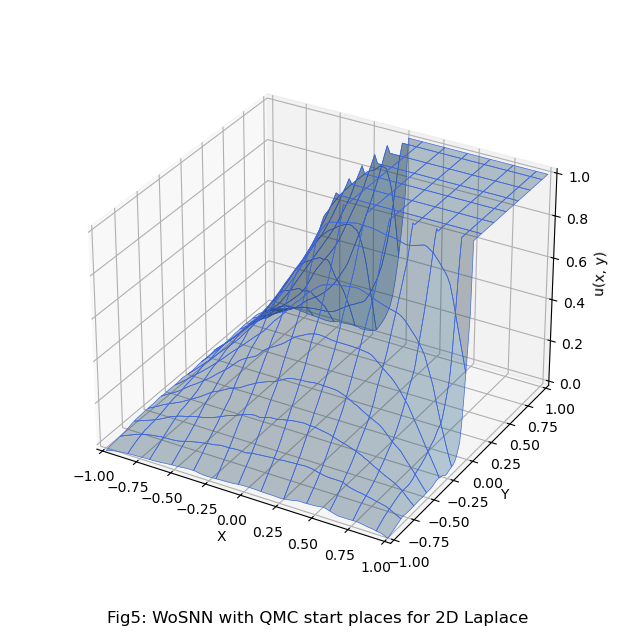

In [103]:

import matplotlib.pyplot as plt
ax = plt.figure(figsize = (8, 8)).add_subplot(projection='3d')

# Plot the 3D surface
ax.plot_surface(X, Y, Z2, edgecolor='royalblue', lw=0.5, rstride=8, cstride=8,
                alpha=0.3)

ax.set(xlim=(-1, 1), ylim=(-1, 1), zlim=(0, 1),
       xlabel='X', ylabel='Y', zlabel='u(x, y)')

#ax.view_init(30, 90)
ax.set_box_aspect(None, zoom=0.85)
ax.set_title("Fig5: WoSNN with QMC start places for 2D Laplace", y=-0.01)
#plt.show()
plt.savefig('WoSNNqmc2Dlaplace.png', bbox_inches='tight')

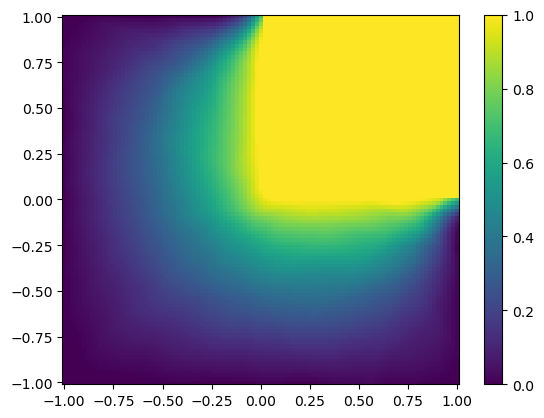

In [104]:
z_min, z_max = -np.abs(Z2).max(), np.abs(Z2).min()
fig, ax = plt.subplots()
c = ax.pcolormesh(X, Y, Z2, cmap = 'viridis', vmin = 0, vmax = 1)
#ax.axis([-1, 1, -1, 1])
fig.colorbar(c, ax = ax)
#plt.show()
plt.savefig('WoSNNLregion.png', bbox_inches='tight')

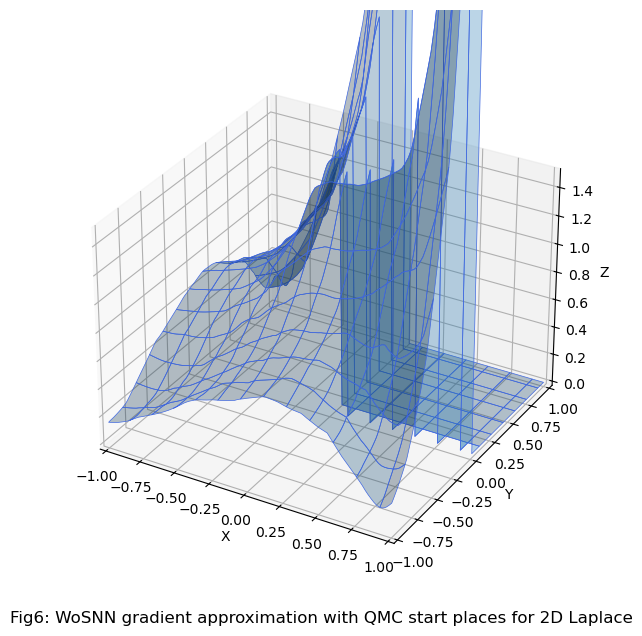

In [105]:
Z3 = np.linalg.norm(np.array(Z)[:, :, 1:3].reshape(-1, 2), axis = 1).reshape(101, 101)
Z1 = np.sqrt(X*X + Y*Y)

import matplotlib.pyplot as plt
ax = plt.figure(figsize = (8, 8)).add_subplot(projection='3d')

# Plot the 3D surface
ax.plot_surface(X, Y, Z3, edgecolor='royalblue', lw=0.5, rstride=8, cstride=8,
                alpha=0.3)
#ax.plot_surface(X, Y, Z1, edgecolor='red', lw=0.5, rstride=8, cstride=8,
#                alpha=0.3)

ax.set(xlim=(-1, 1), ylim=(-1, 1), zlim=(0, 1.5),
       xlabel='X', ylabel='Y', zlabel='Z')

ax.set_box_aspect(None, zoom=0.85)
ax.set_title("Fig6: WoSNN gradient approximation with QMC start places for 2D Laplace", y=-0.01)
#plt.show()
plt.savefig('WoSNN2DqmclaplaceGradient.png', bbox_inches='tight')

In [106]:
print("WoSNN mean gradient error for 10000 test points: " + str(np.mean(abs(Z3-Z1))))

WoSNN mean gradient error for 10000 test points: 0.6831465360984563


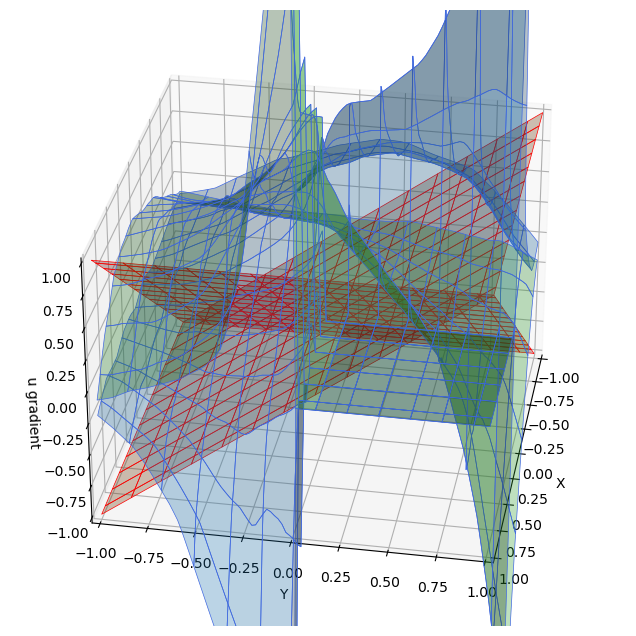

In [107]:
X1 = np.array(Z)[:, :, 1].reshape(101, 101)
X2 = Y
Y1 = np.array(Z)[:, :, 2].reshape(101, 101)
Y2 = X

import matplotlib.pyplot as plt
ax = plt.figure(figsize = (8, 8)).add_subplot(projection='3d')

# Plot the 3D surface
ax.plot_surface(X, Y, X1, edgecolor='royalblue', lw=0.5, rstride=8, cstride=8,
                alpha=0.3, label = 'gradient of x')
ax.plot_surface(X, Y, X2, edgecolor='red', lw=0.5, rstride=8, cstride=8,
                alpha=0.3)
ax.plot_surface(X, Y, Y1, edgecolor='royalblue', lw=0.5, rstride=8, cstride=8,
                alpha=0.3, label = 'gradient of y')
ax.plot_surface(X, Y, Y2, edgecolor='red', lw=0.5, rstride=8, cstride=8,
                alpha=0.3)

ax.set(xlim=(-1, 1), ylim=(-1, 1), zlim=(-1, 1),
       xlabel='X', ylabel='Y', zlabel='u gradient')

ax.view_init(30, 10)

#ax.set_box_aspect(None, zoom=0.85)
#ax.set_title("Fig4: WoSNN gradient approximation with evenly distributed start places for 2D Laplace", y=-0.01)
plt.show()
#plt.savefig('WoSNNeven2DlaplaceGradient.png', bbox_inches='tight')

(101, 101)


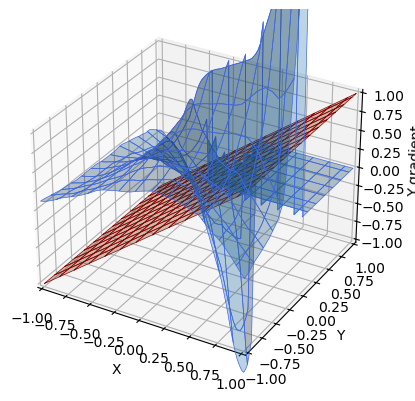

In [108]:
Y1 = np.array(Z)[:, :, 2].reshape(101, 101)
Y2 = X
print(Y1.shape)

import matplotlib.pyplot as plt
ax = plt.figure().add_subplot(projection='3d')

# Plot the 3D surface
ax.plot_surface(X, Y, Y1, edgecolor='royalblue', lw=0.5, rstride=8, cstride=8,
                alpha=0.3)
ax.plot_surface(X, Y, Y2, edgecolor='darkred', lw=0.5, rstride=8, cstride=8,
                alpha=0.3)

ax.set(xlim=(-1, 1), ylim=(-1, 1), zlim=(-1, 1),
       xlabel='X', ylabel='Y', zlabel='Y gradient')

plt.show()

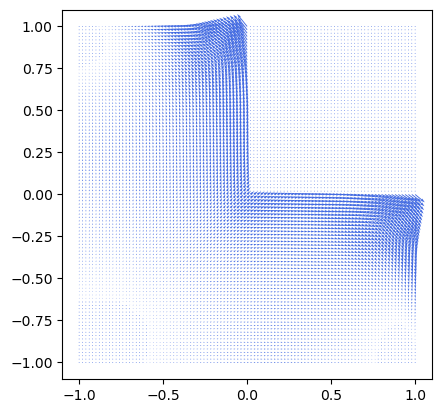

In [109]:
x = np.arange(-1, 1.02, 0.02)
y = np.arange(-1, 1.02, 0.02)
 
# Creating gradient
X, Y = np.meshgrid(x, y)
Z4 = X * Y
dx, dy = np.gradient(Z4)
Z3 = np.array(Z)[:, :, 1:3].reshape(-1, 2)

 
# Creating plot 
fig, ax = plt.subplots()
#ax.quiver(X, Y, dx, dy, color = 'red')
ax.quiver(X, Y, Z3[:, 0].reshape(101, 101), Z3[:, 1].reshape(101, 101), color = 'royalblue')
 
#ax.xaxis.set_ticks([])
#ax.yaxis.set_ticks([])
ax.set_aspect('equal')
 
# show plot
plt.show()

# Finite difference

In [110]:
def solve_laplace_lshape(nx=101, ny=101, max_iter=10000, tol=1e-6, bc=1.0):
    """
    Solve Laplace's equation on an L-shaped domain using finite differences
    
    Parameters:
        nx, ny : grid dimensions
        max_iter : maximum iterations
        tol : convergence tolerance
        bc_top : boundary condition value at top
    """
    # Create grid
    dx = 2.0 / (nx - 1)
    dy = 2.0 / (ny - 1)
    
    # Initialize solution array
    u = np.zeros((ny, nx))
    
    # Define L-shaped domain mask (True = interior point)
    domain = np.zeros((nx, ny), dtype=bool)
    domain[1:nx-1, 1:ny//2] = True  # Vertical leg
    domain[1:nx//2, ny//2:ny-1] = True  # Horizontal leg
    
    # Set boundary conditions
    u[nx//2:, ny//2:] = bc#non-zero boundary
  
    
    # Jacobi iteration
    for iteration in range(max_iter):
        u_old = u.copy()
        max_diff = 0.0
        
        # Update interior points
        for j in range(1, ny-1):
            for i in range(1, nx-1):
                if domain[i, j]:
                    # Standard 5-point stencil
                    u[i, j] = 0.25 * (u_old[i,j+1] + u_old[i,j-1] + 
                                      u_old[i+1,j] + u_old[i-1,j])
                    
                    # Track maximum change
                    diff = abs(u[i, j] - u_old[i, j])
                    if diff > max_diff:
                        max_diff = diff
        
        # Check for convergence
        if max_diff < tol:
            print(f"Converged after {iteration} iterations")
            break
    else:
        print(f"Did not converge after {max_iter} iterations")
    
    return u, domain

In [111]:
# Solve the problem
u, domain = solve_laplace_lshape(nx=101, ny=101, bc=1.0)


Converged after 6541 iterations


In [112]:
nx, ny = u.shape
x = np.linspace(-1, 1, nx//10)
y = np.linspace(-1, 1, ny//10)
Yf, Xf = np.meshgrid(y, x)

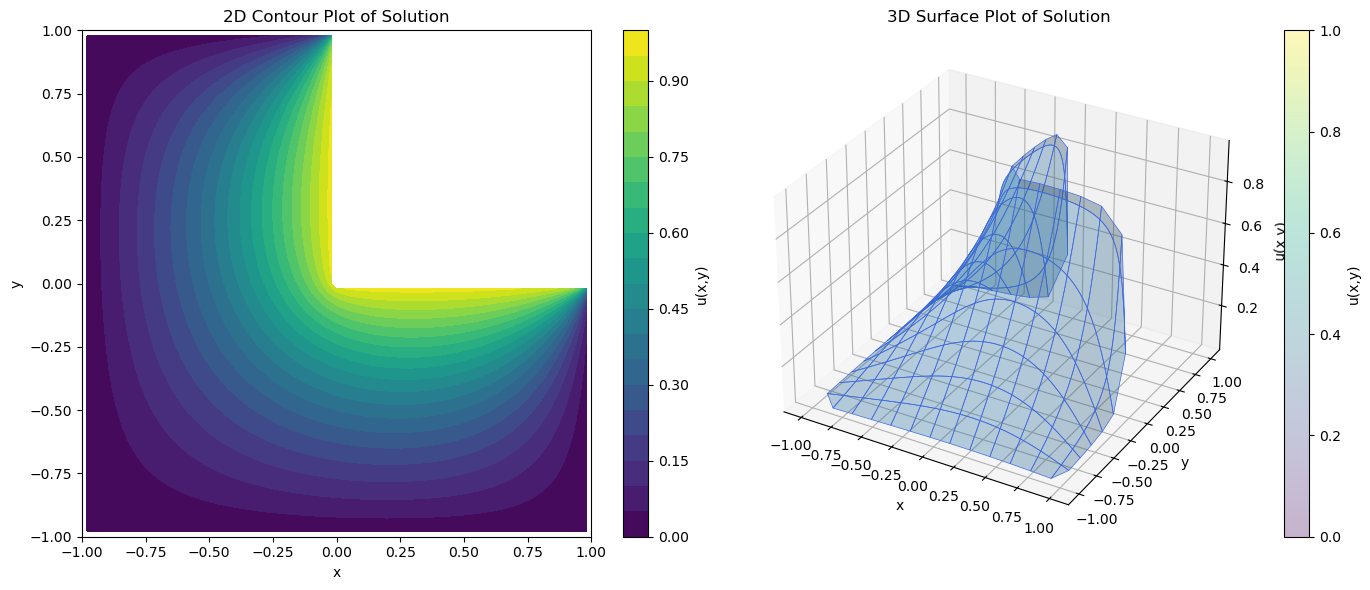

In [113]:
# Create grid for plotting
# nx, ny = u.shape
# x = np.linspace(-1, 1, nx)
# y = np.linspace(-1, 1, ny)
# Xf, Yf = np.meshgrid(x, y)

# Mask points outside domain
u_plot = np.where(domain, u, np.nan)

# Create figure
plt.figure(figsize=(14, 6))

# 2D contour plot
plt.subplot(1, 2, 1)
contour = plt.contourf(X, Y, u_plot, levels=20, cmap='viridis')
plt.title('2D Contour Plot of Solution')
plt.xlabel('x')
plt.ylabel('y')
plt.colorbar(contour, label='u(x,y)')

# 3D surface plot
ax = plt.subplot(1, 2, 2, projection='3d')
surf = ax.plot_surface(X, Y, u_plot, edgecolor='royalblue', lw=0.5, rstride=8, cstride=8,
                alpha=0.3)
ax.set_title('3D Surface Plot of Solution')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('u(x,y)')
plt.colorbar(surf, ax=ax, label='u(x,y)')

plt.tight_layout()
plt.show()

In [114]:
print("WoSNN mean error wrt finite difference approximation: {:.10f}".format(np.abs(Z2-u).mean()))
print("WoSNN relative mean error wrt finite difference approximation: {:.3f}%".format(100*np.abs(Z2-u).mean()/np.abs(u).mean()))

WoSNN mean error wrt finite difference approximation: 0.0081020874
WoSNN relative mean error wrt finite difference approximation: 1.745%


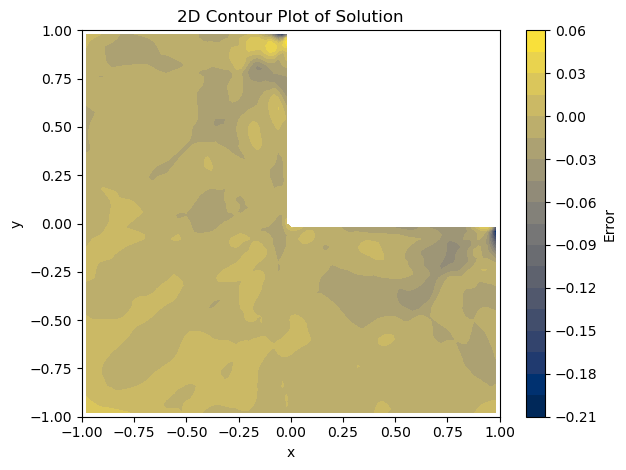

In [115]:

# Create grid for plotting
# nx, ny = u.shape
# x = np.linspace(-1, 1, nx)
# y = np.linspace(-1, 1, ny)
# Xf, Yf = np.meshgrid(x, y)

# Mask points outside domain
u_plot = np.where(domain, u, np.nan)

# 2D contour plot
# plt.subplot(1, , 1)
contour = plt.contourf(X, Y, u_plot-Z2, levels=20, cmap='cividis')
plt.title('2D Contour Plot of Solution')
plt.xlabel('x')
plt.ylabel('y')
plt.colorbar(contour, label='Error')

# # 3D surface plot
# ax = plt.subplot(1, 2, 2, projection='3d')
# surf = ax.plot_surface(X, Y, u_plot, edgecolor='royalblue', lw=0.5, rstride=8, cstride=8,
#                 alpha=0.3)
# ax.set_title('3D Surface Plot of Solution')
# ax.set_xlabel('x')
# ax.set_ylabel('y')
# ax.set_zlabel('u(x,y)')
# plt.colorbar(surf, ax=ax, label='u(x,y)')

plt.tight_layout()
plt.show()

In [ ]:
my_data = genfromtxt('fdm_sol_u_100.csv', delimiter=',')
my_domain = genfromtxt('fdm_sol_d_100.csv', delimiter=',')

array([[       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan, 0.00029019, 0.00058037, ..., 0.0011646 , 0.000583  ,
               nan],
       [       nan, 0.00058037, 0.00116076, ..., 0.00233198, 0.00116739,
               nan],
       ...,
       [       nan, 0.0011646 , 0.00233198, ...,        nan,        nan,
               nan],
       [       nan, 0.000583  , 0.00116739, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan]])

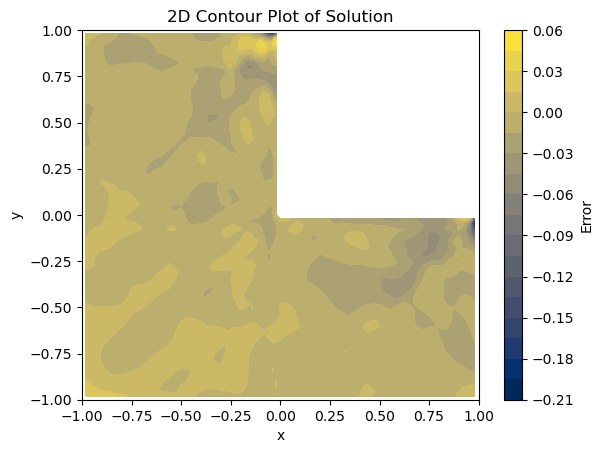

In [ ]:
# Create grid for plotting
nx, ny = u.shape
x = np.linspace(-1, 1, 1001)
y = np.linspace(-1, 1, 1001)
Xf, Yf = np.meshgrid(x, y)

# Mask points outside domain
u_plot = np.where(my_domain, my_data, np.nan)

contour = plt.contourf(Xf, Yf, u_plot-Z2, levels=20, cmap='cividis')
plt.title('2D Contour Plot of Solution')
plt.xlabel('x')
plt.ylabel('y')
plt.colorbar(contour, label='Error');